<a href="https://colab.research.google.com/github/Venkateshwarlu978/Venkateshwarlu978/blob/main/Random_Forest_classification%20and%20Regression%20with%20Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Travel.csv')

In [ ]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


Data cleaning
1.Handling Missing values
2.handling Duplicates
3.checking data type(numeric,categorical)
4.understand the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [ ]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [ ]:
##chacking all the categories
df['Gender'].value_counts() #Fe Male has speeling mistake,we need to combine it with Female

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [ ]:
df['MaritalStatus'].value_counts() #need to combine single and unmarried

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [ ]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [ ]:
df['Gender']=df['Gender'].replace('Fe Male','Female')


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1972


In [ ]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Unmarried,1598
Divorced,950


In [ ]:
#checking Missing Values
#these are the features with nan values
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
  print(feature,np.round(df[feature].isnull().mean()*100,5),'% missing values')




Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [ ]:
#statistics on  numerical columns(null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


# Imputing Null values
1.Impute median value for age columns
2.Mode for type of contract
3.median for duration of pitch
4.mode for number of followup as it is discrete feature
5.mode for prefferedPowerStar
6.median for Number of trips
7.mode for number of childrenvisiting
8.impute median for monthlyincome

In [ ]:
#Age
df.Age.fillna(df.Age.median(),inplace=True)
#TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
#DurationofPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
#NumberofFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)
#PrefferedPropertystar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
#NumberoofTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)
#NumberofChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)
#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)


In [ ]:
df.drop('CustomerID',inplace=True,axis=1)

In [ ]:
df.isnull().sum()

,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0
ProductPitched,0


In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


Feature Engineering

--->feature Extraction

In [ ]:
#create new column for feature
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],axis=1)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [ ]:
#get all the numeric features
num_features=[feature for feature in df.columns if df[feature].dtype !='O']
print('Num of numerical features:',len(num_features))

Num of numerical features: 14


In [ ]:
#get all the numeric features
num_features=[feature for feature in df.columns if df[feature].dtype !='O']
print('Num of numerical features:',len(num_features))
#categorical features
cat_features=[feature for feature in df.columns if df[feature].dtype =='O']
print('Num of categorical features:',len(cat_features))
#discreate Categories
dis_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of discreate features:',len(dis_features))
#continuous features
con_features = [feature for feature in num_features if df[feature].nunique() > 25]
print('Num of continuous features:', len(con_features))

Num of numerical features: 14
Num of categorical features: 6
Num of discreate features: 11
Num of continuous features: 3


In [ ]:
cat_features=[feature for feature in df.columns if df[feature].dtype =='O']
print('Num of categorical features:',len(cat_features))

Num of categorical features: 6


In [ ]:
#discreate Categories
dis_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of discreate features:',len(dis_features))

Num of discreate features: 11


In [ ]:
#continuous features
con_features = [feature for feature in num_features if df[feature].nunique() > 25]
print('Num of continuous features:', len(con_features))

Num of continuous features: 3


Train Test Split and Model Training


In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [ ]:
y.value_counts()

,count
ProdTaken,
0,3968
1,920


In [ ]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,2.0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
X_train.shape,X_test.shape

((3910, 19), (978, 19))

In [ ]:
 #Create Column Transformer with 3 types of Transformers
 cat_features=X.select_dtypes(include='object').columns
 num_features=X.select_dtypes(exclude='object').columns
 from sklearn.preprocessing import OneHotEncoder,StandardScaler
 from sklearn.compose import ColumnTransformer

 numeric_transformer=StandardScaler()
 oh_transformer=OneHotEncoder(drop='first')

 preprocessor=ColumnTransformer([
     ("OneHotEncoder",oh_transformer,cat_features),
     ("StandardScaler",numeric_transformer,num_features)
 ])

In [ ]:
#applying transformation in training set(fit_transfrom)
X_train=preprocessor.fit_transform(X_train)

In [ ]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.252472,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.218050,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.129347,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,0.956297,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.218050,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.129347,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,-0.218050,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.511165,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,2.130645,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,0.956297,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.129347,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,-0.218050,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,0.956297,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.129347,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,0.956297,-0.252799,0.643615


In [ ]:
#apply transformation on test data
X_test=preprocessor.transform(X_test)

In [ ]:
X_test

array([[ 0.        ,  0.        ,  0.        , ..., -0.21805023,
        -0.73751038, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -0.21805023,
        -0.6704111 , -0.06526803],
       [ 1.        ,  0.        ,  0.        , ..., -1.39239789,
        -0.4208322 , -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.95629743,
         0.69001249,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ..., -0.21805023,
        -0.22827818, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  2.13064508,
        -0.44611323,  2.06138184]])

In [ ]:
##applying ML classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_curve,roc_auc_score

In [ ]:
models={
    "logistic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier()

}
for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,y_train) #train_model

  #Make predictions
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)

  #Training set performances
  model_train_accuracy=accuracy_score(y_train,y_train_pred)
  model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
  model_train_roc_curve=roc_curve(y_train,y_train_pred)
  model_train_precision=precision_score(y_train,y_train_pred)
  model_train_recall=recall_score(y_train,y_train_pred)
  model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

  #test performance
  model_test_accuracy=accuracy_score(y_test,y_test_pred)
  model_test_f1=f1_score(y_test,y_test_pred)
  model_test_precision=precision_score(y_test,y_test_pred)
  model_test_recall=recall_score(y_test,y_test_pred)
  model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)


  print(list(models.keys())[i])


  print('model performance for training set')
  print('-Accuracy:{:.4f}'.format(model_train_accuracy))
  print("-F1 score:{:.4f}".format(model_train_f1))
  print('-Precision:{:.4f}'.format(model_train_precision))
  print('-Recall:{:.4f}'.format(model_train_recall))
  print('-Roc Auc Score:{:.4f}'.format(model_train_rocauc_score))

  print("---------------------------------------------------")

  print("Model performance for test set")
  print('-Accuracy:{:.4f}'.format(model_test_accuracy))
  print("-F1 score:{:.4f}".format(model_test_f1))
  print('-Precision:{:.4f}'.format(model_test_precision))
  print('-Recall:{:.4f}'.format(model_test_recall))
  print('-Roc Auc Score:{:.4f}'.format(model_test_rocauc_score))


  print('='*35)
  print('\n')

logistic Regression
model performance for training set
-Accuracy:0.8460
-F1 score:0.8206
-Precision:0.6991
-Recall:0.3059
-Roc Auc Score:0.6379
---------------------------------------------------
Model performance for test set
-Accuracy:0.8354
-F1 score:0.4103
-Precision:0.6829
-Recall:0.2932
-Roc Auc Score:0.6301


Decision Tree
model performance for training set
-Accuracy:1.0000
-F1 score:1.0000
-Precision:1.0000
-Recall:1.0000
-Roc Auc Score:1.0000
---------------------------------------------------
Model performance for test set
-Accuracy:0.9121
-F1 score:0.7701
-Precision:0.7869
-Recall:0.7539
-Roc Auc Score:0.8522


Random Forest
model performance for training set
-Accuracy:1.0000
-F1 score:1.0000
-Precision:1.0000
-Recall:1.0000
-Roc Auc Score:1.0000
---------------------------------------------------
Model performance for test set
-Accuracy:0.9202
-F1 score:0.7532
-Precision:0.9520
-Recall:0.6230
-Roc Auc Score:0.8077


Gradient Boost
model performance for training set
-Accurac

In [ ]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

Adaboost technique

In [ ]:
adaboost_param={
    "n_estimators":[50,60,70,80,90],
    "algorithm":['SAMME','SAMME.R']
}

In [ ]:
adaboost_param

{'n_estimators': [50, 60, 70, 80, 90], 'algorithm': ['SAMME', 'SAMME.R']}

In [ ]:
#Model list for Hyperparameter Tunning
randomcv_models=[
                  ("RF",RandomForestClassifier(),rf_params),
                  ("AB",AdaBoostClassifier(),adaboost_param

)]

In [ ]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('AB',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 80, 90], 'algorithm': ['SAMME', 'SAMME.R']})]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=10,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}
---------------- Best Params for AB -------------------
{'n_estimators': 80, 'algorithm': 'SAMME'}


In [ ]:
models={

    "Random Forest":RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=7,max_depth=None),
    "adaboost":AdaBoostClassifier(n_estimators=80, algorithm='SAMME')
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))



    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))


    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9294
- F1 score: 0.9241
- Precision: 0.9692
- Recall: 0.6597
- Roc Auc Score: 0.8273


adaboost
Model performance for Training set
- Accuracy: 0.8465
- F1 score: 0.8132
- Precision: 0.7699
- Recall: 0.2524
- Roc Auc Score: 0.6176
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.7977
- Precision: 0.7818
- Recall: 0.2251
- Roc Auc Score: 0.6049




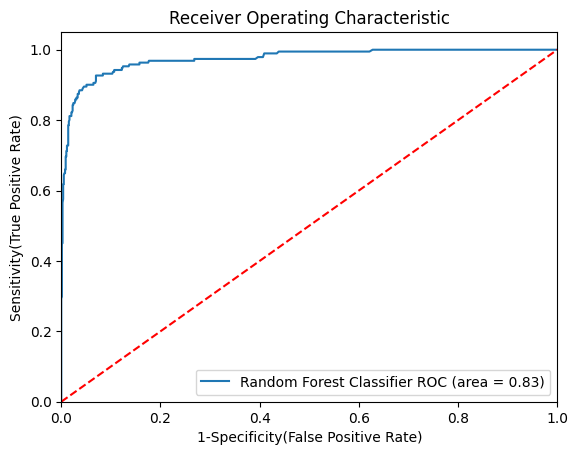

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model':RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=7,max_depth=None),
    'auc':  0.8273
},

]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()

Roc curve fro adaboost

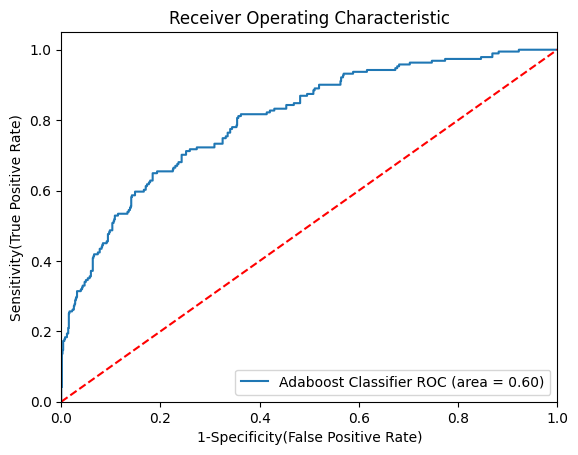

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Adaboost Classifier',
    'model': AdaBoostClassifier(n_estimators=80, algorithm='SAMME'),

    'auc':  0.6049
},

]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()

# Random Forest Regression

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df=pd.read_csv("cardekho_imputated.csv")

In [71]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Feature engineering

In [72]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [73]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [74]:
df.drop(columns=['car_name','brand','Unnamed: 0'],axis=1,inplace=True)

In [75]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [76]:
df['model'].unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

In [77]:
#get all the numeric features
num_features=[feature for feature in df.columns if df[feature].dtype !='O']
print('Num of numerical features:',len(num_features))
#categorical features
cat_features=[feature for feature in df.columns if df[feature].dtype =='O']
print('Num of categorical features:',len(cat_features))
#discreate Categories
dis_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of discreate features:',len(dis_features))
#continuous features
con_features = [feature for feature in num_features if df[feature].nunique() > 25]
print('Num of continuous features:', len(con_features))

Num of numerical features: 7
Num of categorical features: 4
Num of discreate features: 2
Num of continuous features: 5


In [78]:
#Independent and dependend features
from sklearn.model_selection import train_test_split
X=df.drop(['selling_price'],axis=1)
y=df['selling_price']

In [79]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [80]:
y

,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000
...,...
15406,250000
15407,925000
15408,425000
15409,1225000


# Feature engineering and scaling

In [81]:
len(df['model'].unique())

120

In [82]:
df['model'].value_counts()

,count
model,
i20,906
Swift Dzire,890
Swift,781
Alto,778
City,757
...,...
Altroz,1
C,1
Ghost,1


In [83]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X['model']=le.fit_transform(X['model'])

In [84]:
X.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,7,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,54,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,118,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,7,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,38,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [85]:
len(df['seller_type'].unique()),len(df['transmission_type'].unique()),len(df['fuel_type'].unique())

(3, 2, 5)

In [86]:
#create column transformer with 3 types of transformers
num_features=X.select_dtypes(exclude='object').columns
onehot_columns=['seller_type','fuel_type','transmission_type']
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer([
     ("OneHotEncoder",oh_transformer,onehot_columns),
     ("StandardScaler",numeric_transformer,num_features)
],remainder='passthrough')

🔹 When to use remainder='passthrough'

Use it when:

You want to keep some columns as-is (e.g., IDs or already processed features)

You’re not sure yet if you’ll need the other columns later

You want to avoid accidentally dropping important data

In [87]:
X=preprocessor.fit_transform(X)


In [88]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.519714,0.983562,1.247335,-0.000276,-1.324259,-1.263352,-0.403022
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.225693,-0.343933,-0.690016,-0.192071,-0.554718,-0.432571,-0.403022
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.536377,1.647309,0.084924,-0.647583,-0.554718,-0.479113,-0.403022
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.519714,0.983562,-0.360667,0.292211,-0.936610,-0.779312,-0.403022
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.666211,-0.012060,-0.496281,0.735736,0.022918,-0.046502,-0.403022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.508844,0.983562,-0.869744,0.026096,-0.767733,-0.757204,-0.403022
15407,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.556082,-1.339555,-0.728763,-0.527711,-0.216964,-0.220803,2.073444
15408,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.407551,-0.012060,0.220539,0.344954,0.022918,0.068225,-0.403022
15409,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.426247,-0.343933,72.541850,-0.887326,1.329794,0.917158,2.073444


In [89]:
print(y_train.dtype)
print(y_train.head())

int64
3995    0
2610    0
3083    0
3973    0
4044    0
Name: ProdTaken, dtype: int64


In [90]:
#seperate dataset into train and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((12328, 14), (3083, 14))

Model training and model selection


In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error



In [92]:
#create a function to evalute the model
def evaluate_model(true,predicted):
  r2s=r2_score(true,predicted)
  mae=mean_absolute_error(true,predicted)
  rmse=np.sqrt(mean_squared_error(true,predicted))
  return r2s,mae,rmse

In [95]:
from sklearn.metrics import r2_score
print(r2_score.__module__)

sklearn.metrics._regression


In [96]:
print(y_train[:5])
print(y_train_pred[:5])

11210    1825000
1347      515000
10363    7500000
316       435000
10638     200000
Name: selling_price, dtype: int64
[3265323.35329341  771611.47250148 5246454.02077722  771611.47250148
  771611.47250148]


In [97]:
#Beginning the Model Training
models={
    'Linear Regression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'K-Nei':KNeighborsRegressor(),
    'DTR':DecisionTreeRegressor(),
    'Rfr':RandomForestRegressor(),
    'ada':AdaBoostRegressor()
}
for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,y_train)#Train model

  #Make predictions
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)

  #evaluate train and test Datasets
  model_train_r2,model_train_mae,model_train_rmse=evaluate_model(y_train,y_train_pred)
  model_test_r2,model_test_mae,model_test_rmse=evaluate_model(y_test,y_test_pred)

  print(list(models.keys())[i])
  print('Model performance for Training set')
  print('Root Mean Squared Error:{:.4f}'.format(model_train_rmse))
  print('Mean Absolute Error:{:.4f}'.format(model_train_mae))
  print('r2 score:{:.4f}'.format(model_train_r2))

  print('-----------------------------------------')

  print('Model performance for Test set')
  print('Root Mean Squared Error:{:.4f}'.format(model_test_rmse))
  print('Mean Absolute Error:{:.4f}'.format(model_test_mae))
  print('r2 score:{:.4f}'.format(model_test_r2))


  print('='*35)
  print('\n')

Linear Regression
Model performance for Training set
Root Mean Squared Error:553855.6665
Mean Absolute Error:268101.6071
r2 score:0.6218
-----------------------------------------
Model performance for Test set
Root Mean Squared Error:502543.5930
Mean Absolute Error:279618.5794
r2 score:0.6645


Lasso
Model performance for Training set
Root Mean Squared Error:553855.6710
Mean Absolute Error:268099.2226
r2 score:0.6218
-----------------------------------------
Model performance for Test set
Root Mean Squared Error:502542.6696
Mean Absolute Error:279614.7461
r2 score:0.6645


Ridge
Model performance for Training set
Root Mean Squared Error:553856.3160
Mean Absolute Error:268059.8015
r2 score:0.6218
-----------------------------------------
Model performance for Test set
Root Mean Squared Error:502533.8230
Mean Absolute Error:279557.2169
r2 score:0.6645


K-Nei
Model performance for Training set
Root Mean Squared Error:325885.9831
Mean Absolute Error:91430.9701
r2 score:0.8691
------------

Hyperparameter Tunning

In [98]:
#Initialize few parameter for Hyperparamter tuning
knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}



In [100]:
ada_params={'n_estimators':[50,60,70,80,90,100],
            'loss':['linear','square','exponential']
            }

In [101]:
# Models list for Hyperparameter tuning
randomcv_models = [('KNN', KNeighborsRegressor(), knn_params),
                   ("RF", RandomForestRegressor(), rf_params),
                   ('ada',AdaBoostRegressor(),ada_params)

]

In [102]:
##Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=6,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
---------------- Best Params for KNN -------------------
{'n_neighbors': 10}
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 5, 'max_depth': 10}
---------------- Best Params for ada -------------------
{'n_estimators': 50, 'loss': 'linear'}


In [103]:
## Retraining the models with best parameters
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, min_samples_split=2, max_features='sqrt', max_depth=None,
                                                     n_jobs=-1),
     "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    "ada boost":AdaBoostRegressor(n_estimators= 50, loss='linear')

}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_r2 , model_train_mae, model_train_rmse = evaluate_model(y_train, y_train_pred)

    model_test_r2 , model_test_mae, model_test_rmse = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 131911.2761
- Mean Absolute Error: 40352.7418
- R2 Score: 0.9785
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 208132.8809
- Mean Absolute Error: 99252.2982
- R2 Score: 0.9425


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 363465.6927
- Mean Absolute Error: 103489.6090
- R2 Score: 0.8371
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 263849.8119
- Mean Absolute Error: 117481.4548
- R2 Score: 0.9075


ada boost
Model performance for Training set
- Root Mean Squared Error: 446528.8878
- Mean Absolute Error: 327615.5036
- R2 Score: 0.7542
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 481859.8894
- Mean Absolute Error: 345266.6828
- R2 Score: 0.6916


